In [1]:
import numpy as np
import matplotlib.pyplot as plt

import io, requests, pandas as pd
TAP_URL='https://exoplanetarchive.ipac.caltech.edu/TAP/sync'

query='''
SELECT
    pl_orbper,
    pl_rade,
    pl_eqt,
    st_met,
    discoverymethod
FROM pscomppars
'''
r=requests.get(TAP_URL, params={"query":query, "format":"csv"}, timeout=120)
exo=pd.read_csv(io.StringIO(r.text))
exo.head()

,pl_orbper,pl_rade,pl_eqt,st_met,discoverymethod
0,1.003934,1.710000,1419.0,-0.05,Transit
1,8.172400,3.323214,858.0,-0.06,Transit
2,6.283855,0.800000,1108.0,0.07,Transit
3,3.173917,3.150000,1655.0,0.08,Transit
4,56.358501,4.540605,419.0,-0.20,Transit


In [12]:
vj=[] #pravim listu u koju cu kasnije upisivati 0 ili 1 u zavisnosti od toga da li je planeta vruci Jupiter ili ne
udeovj=0 #brojim koliko takvih planeta ima
for i in range(exo.shape[0]): #prolazim kroz sve redove
    if exo["pl_orbper"][i]<10 and exo["pl_rade"][i]>8: #proveravam da li planeta odgovara opisu vruceg Jupitera
        vj.append(1) #ako da, onda dodajem jedinicu na listu
        udeovj=udeovj+1 #i prebrojavam i tu planetu kao vreli Jupiter
    else: #ukoliko uslov ne vazi
        vj.append(0) #u listu mi se upisuje nula
udeovrucihjupitera=(100*udeovj)/exo.shape[0] #racunam udeo vrucih Jupitera preko proporcije 100:broj planeta=udeo vrucih jupitera:broj vrucih jupitera
print("Udeo vrucih Jupitera je ",udeovrucihjupitera,"%") #stampam

Udeo vrucih Jupitera je  11.778731521220791 %


In [14]:
m04=0 #brojac koji cu koristiti da brojim planete koje ispunjuju uslov [Fe/H]>0.4
m04vj=0 #brojac koji broji koliko je planeta cija je [Fe/H]>0.4 i ispunjavanju uslov za vruci Jupiter
for i in range(exo.shape[0]): #prolazim kroz sve redove
    if exo["st_met"][i]>0.4: #uslov za metalicnost
        m04=m04+1 #ubrajam planetu za koju je ispunjeno [Fe/H]>0.4
        if exo["pl_orbper"][i]<10 and exo["pl_rade"][i]>8: #uslov za vruce Jupitere
            m04vj=m04vj+1 #ubrajam vruci Jupiter za koji vazi [Fe/H]>0.4

udeovrucihjupitera_m04=(100*m04vj)/m04 #racunam udeo vrucih Jupitera u uzorku planeta za koje je [Fe/H]>0.4
print("Udeo vrucih Jupitera u uzorku [Fe/H]>0.4 je ",udeovrucihjupitera_m04,"%") #printujem

Udeo vrucih Jupitera u uzorku [Fe/H]>0.4 je  36.36363636363637 %


## Bootstrap

U kodu ispod je primenjeno Bootstrap sampleovanje kako bi se numericki procenila nesigurnost srednje vrednosti i standardne devijacije metalicnosti i uporedila sa formulama

BOOTSTRAP:
sigma mean: 0.0071143990429985825
sigma s: 0.01214145830503729

ANALITIČKI:
sigma mean: 0.007240015671030045
sigma s: 0.005153034793481672


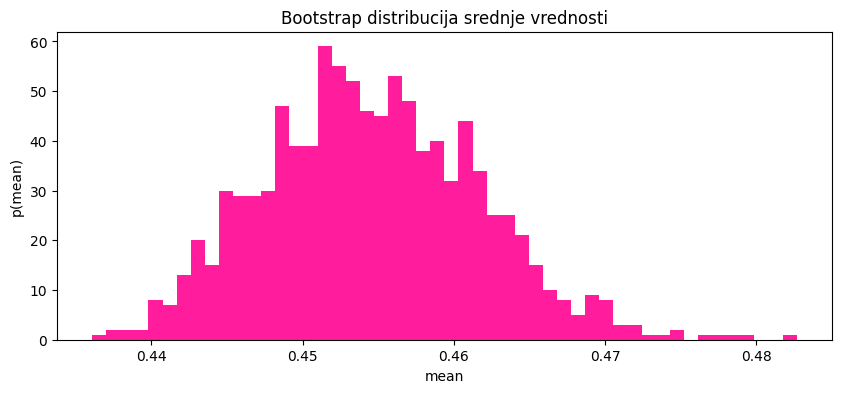

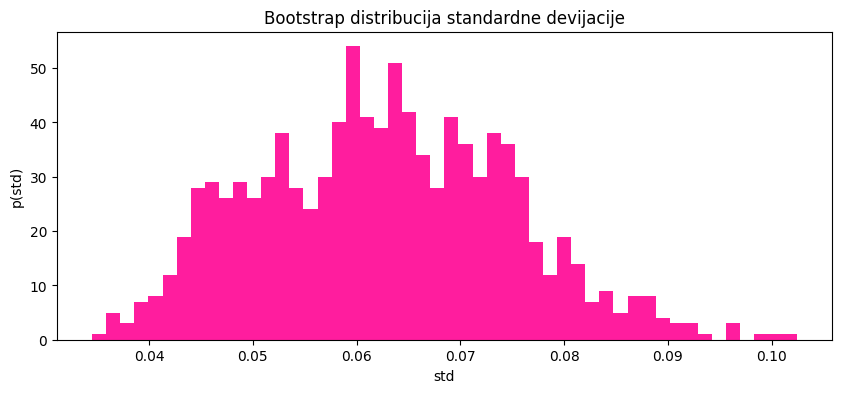

In [19]:
from scipy.stats import bootstrap #importujem biblioteku


uzorak=exo[exo["st_met"] > 0.4]["st_met"] #razmatram metalicnost svih planeta za koje je [Fe/H]>0.4      
N=1000 #ovoliko puta cu "ponoviti merenje"

rez_mean = bootstrap( #pozivam funkciju
    (uzorak,), #uzimam 'uzorak' u razmatranje
    np.mean, #racunam srednje vrednosti za svaki resample
    n_resamples=N, #N puta ponavljam
    random_state=42 #fiksirana slucajnost
)
mean_boot = rez_mean.bootstrap_distribution #lista bootstrap srednjih vrednosti
rez_std = bootstrap( 
    (uzorak,), #razmatram uzorak
    lambda x: np.std(x, ddof=1), #neimenovana funkcija uzima uzorak x i racuna standardnu devijaciju
    n_resamples=N,
    random_state=42
)

std_boot = rez_std.bootstrap_distribution #lista bootstrap std vrednosti
s = np.std(uzorak, ddof=1) #racunam stvarni std uzorka

sigma_x_boot = np.std(mean_boot) #sada raacunam std vrednosti koje sam dobila iz niza eksperimenata kako bih procenila varijabilnost

sigma_x_anal = s / np.sqrt(len(uzorak)) #koristim formule za sigma mean i sigma s
sigma_s_anal = s / np.sqrt(2 * (len(uzorak) - 1))

print("BOOTSTRAP:") #stampam dobijene vrednosti
print("sigma mean:", sigma_x_boot)
print("sigma s:", sigma_s_boot)

print("\nANALITIČKI:")
print("sigma mean:", sigma_x_anal)
print("sigma s:", sigma_s_anal)

plt.figure(figsize=(10, 4))
plt.hist(mean_boot, bins=50, color='#ff1d9e') #pravim histogram da bih videla koliko su pojedine srednje i std vrednosti zastupljene i kako je ta zastupljenost rasporedjena
plt.title("Bootstrap distribucija srednje vrednosti")
plt.xlabel("mean")
plt.ylabel("p(mean)")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(std_boot, bins=50, color='#ff1d9e')
plt.title("Bootstrap distribucija standardne devijacije")
plt.xlabel("std")
plt.ylabel("p(std)")
plt.show()

Po Central Limit Theorem, raspodela srednjih vrednosti tezi normalnoj, dok to u opstem slucaju ne vazi za standardnu devijaciju, pa je, prema tome, pretpostavka normalnosti opravdana za srednju vrednost.

Za srednju vrednost ce podjednako dobro raditi i Bootstrap i Jackknife, dok ce Bootstrap biti bolji za standardnu devijaciju zbog njene nelinearnosti. Standardna devijacija je jako osetljiva na ouliere, te Jackknife, menjajuci uzorak lokalno, lose aproksimira nesigurnost standardne devijacije

## GaussianMixture

GaussianMixture model kombinuje vise normalnih raspodela

AIC bira optimalni broj komponenata

Optimalan broj komponenti (Rp): 10


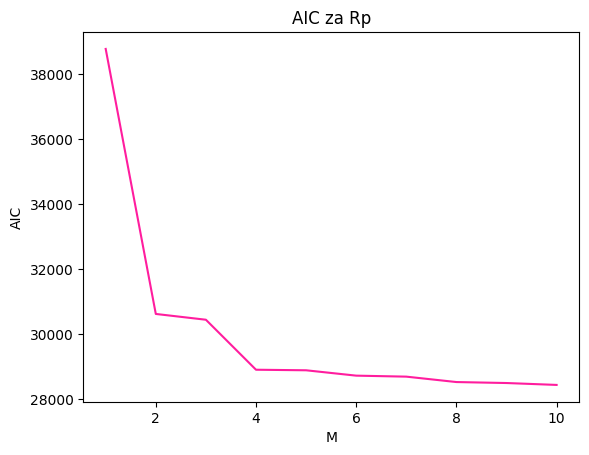

In [42]:
from sklearn.mixture import GaussianMixture as GM

Rp = exo["pl_rade"].dropna().values.reshape(-1, 1) #uzimam podatke za radijuse planeta

N = np.arange(1, 11) #niz od 1 do 10 kao moguci brojevi Gaussian komponenti 
modeli = [] #prazna lista u koju cu upisivati modele kasnije

for k in N:#prolazim kroz komponente od 1 do 10
    gm = GM(k).fit(Rp)#pravim GMM sa k Gausovih distribucija
    modeli.append(gm) #cuvam model

AIC = [m.aic(Rp) for m in modeli] #racunam AIC za svaki model

M = N[np.argmin(AIC)] #nalazim indeks najmanjeg AIC-a
best_model = modeli[np.argmin(AIC)] #uzimam najbolji model  

print("Optimalan broj komponenti (Rp):", M) #printujem

plt.plot(N, AIC, color='#ff1d9e') #plotujem zavisnost AIC vrednosti od broja komponenti 
plt.xlabel("M")
plt.ylabel("AIC")
plt.title("AIC za Rp")
plt.show()

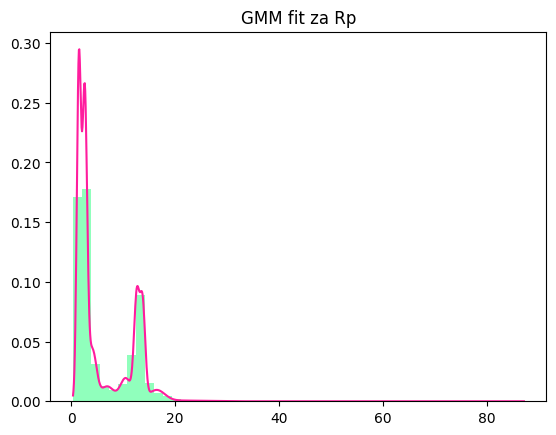

In [27]:
x = np.linspace(Rp.min(), Rp.max(), 1000).reshape(-1, 1) #1000 tacaka ravnomerno rasporedjenih izmedju najmanjeg i najveceg radijusa i reshapeovanih u 2D niz
pdf = np.exp(best_model.score_samples(x)) #eksponent zato sto score_samples(x) daje logaritmovanu verovatnocu

plt.hist(Rp, bins=50, density=True, alpha=0.5, color='#22ff7b') #histogram mi pokazuje kakva je raspodela planeta po razlicitim radijusima
plt.plot(x, pdf,color='#ff1d9e') #modelovana kriva raspodele iz GMM-a
plt.title("GMM fit za Rp")
plt.show()

Optimalan M (Transit): 8


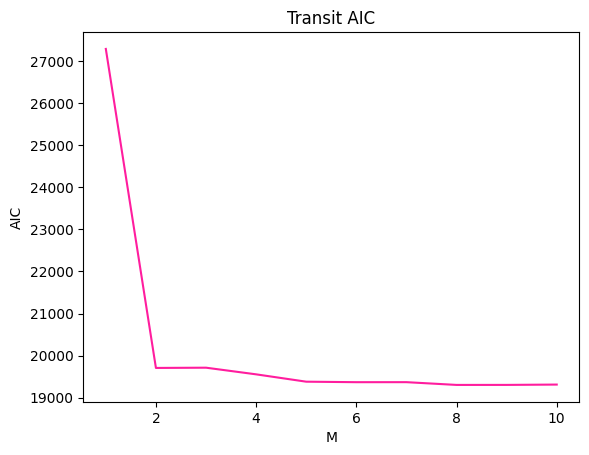

In [44]:
Rp_tr = exo[exo["discoverymethod"] == "Transit"]["pl_rade"].dropna().values.reshape(-1, 1) #zelim samo one planete ciji je discovety method tranzit
#ostatak je isti kao malopre
modeli_tr = [] #prazna list za model

for k in N:
    gm = GM(k).fit(Rp_tr)
    modeli_tr.append(gm)

AIC_tr = [m.aic(Rp_tr) for m in modeli_tr]

M_tr = N[np.argmin(AIC_tr)]
best_model_tr = modeli_tr[np.argmin(AIC_tr)]

print("Optimalan M (Transit):", M_tr)

plt.plot(N, AIC_tr, color='#ff1d9e')
plt.xlabel("M")
plt.ylabel("AIC")
plt.title("Transit AIC")
plt.show()

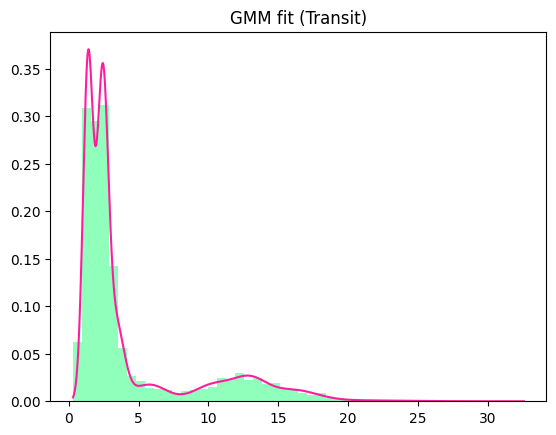

In [45]:
x_tr = np.linspace(Rp_tr.min(), Rp_tr.max(), 1000).reshape(-1, 1)
pdf_tr = np.exp(best_model_tr.score_samples(x_tr))

plt.hist(Rp_tr, bins=50, density=True, alpha=0.5, color='#22ff7b')
plt.plot(x_tr, pdf_tr, color='#ff1d9e')
plt.title("GMM fit (Transit)")
plt.show()

In [52]:
import numpy as np
import io, requests, pandas as pd

TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

#novi zahtev
query = """ 
SELECT
    pl_eqt,
    sy_snum,
    sy_pnum,
    disc_facility,
    pl_bmasse,
    pl_orbeccen
FROM pscomppars
"""

r = requests.get(TAP_URL, params={"query": query, "format": "csv"}, timeout=120)
df = pd.read_csv(io.StringIO(r.text))

Teq_earth = 254 #Zemljina ravnotezna temperatura (https://en.wikipedia.org/wiki/Planetary_equilibrium_temperature)

idx = (np.abs(df["pl_eqt"] - Teq_earth)).idxmin() #nalazim indeks planete sa najmanjom razlikom izmedju njenog i zemljinog Teq
planeta = df.loc[idx]

print("Planeta najbliža Zemljinoj Teq:") #printovanje podataka za trazenu planetu
print(planeta[[
    "sy_snum",
    "sy_pnum",
    "disc_facility",
    "pl_bmasse",
    "pl_orbeccen",
    "pl_eqt"
]])

Planeta najbliža Zemljinoj Teq:
sy_snum                    1
sy_pnum                    1
disc_facility         Kepler
pl_bmasse        1322.166173
pl_orbeccen             0.92
pl_eqt                 253.8
Name: 1551, dtype: object


## Inverzno uzorkovanje i inverzno mapiranje preko ECDF-a

Iz empirijske distribucije podataka se generisu novi uzorci bez pretpostavki o obliku distribucije.

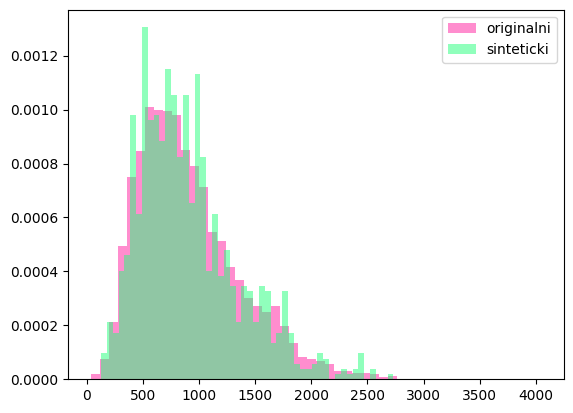

In [47]:
Teq = exo["pl_eqt"].dropna().values #razmatram kolonu ravnoteznih temperatura planeta
Teq_sorted = np.sort(Teq) #sortiram od najmanje do najvece
ecdf = np.arange(1, len(Teq_sorted)+1) / len(Teq_sorted) #za svaki podatak dodeljujem kumulativnu verovatnocu
Nsyn = 1000 #broj sintetickih uzoraka
u = np.random.rand(Nsyn) #verovatnoce

Teq_syn = np.interp(u, ecdf, Teq_sorted) #mapiram verovatnoce nazad u Teq vrednosti i dobijam sinteticke Teq koji prate originalnu distribuciju
plt.hist(Teq, bins=50, density=True, alpha=0.5, label="originalni", color='#ff1d9e') #histogrami
plt.hist(Teq_syn, bins=50, density=True, alpha=0.5, label="sinteticki", color='#22ff7b')
plt.legend()
plt.show()

Ova metoda se razlikuje od Bootstrap metode jer Bootstrap uzima originalni uzorak i pravi nove uzorke iz originalnih podataka i racuna mean, std i ostalo na tim uzorcima, dok ECDF inverzno samplovanje pravi empirijsku raspodelu i onda iz nje generise nove podatke koji lice na originalnu distribuciju.

Na Teq bi GMM bio najpogodniji jer verovatno ne potice iz jedne jedinstvene raspodele, vec predstavlja mesavinu vise fizicki razlicitih populacija planeta. Zbog toga se distribucija moze dobro aproksimirati kao suma nekoliko normalnih raspodela.